# Week 3 — Full Zero-Shot Baseline Evaluation

**Option A: Controllable Synthesis & Editing | MSc Dissertation — Newcastle University**

> **Prerequisites:** week1_data_colab ✓  week1_model_final ✓  week2_explore_colab ✓

**What this does:** Runs LLaVA zero-shot on all 100 test images → BLEU-4 + CLIP score.
This is your **Table 1 baseline row** — every technique in weeks 4-8 is compared against it.

**Literature:** Liu et al. (2023) LLaVA · Radford et al. (2021) CLIP · Alayrac et al. (2022) Flamingo

**Run order every session:** Cell 1 → Cell 2 → Cell 3 → Cell 4 onwards


In [1]:
# ── CELL 1 — Mount Drive ─────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [2]:
# ── CELL 2 — Install packages ─────────────────────────────────────────────
!pip install -q --upgrade accelerate
!pip install -q sentencepiece nltk
import nltk
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
import transformers
print(f'transformers: {transformers.__version__}')
print('Ready. No restart needed.')

transformers: 5.0.0
Ready. No restart needed.


In [3]:
# ── CELL 3 — Paths ────────────────────────────────────────────────────────
import os

BASE          = '/content/drive/MyDrive/dissertation_final'
PROCESSED_DIR = f'{BASE}/data/processed'
RESULTS_DIR   = f'{BASE}/results'
MODEL_CACHE   = f'{BASE}/models/llava_cache'
BASELINE_PROMPT = 'Describe this image in detail.'

os.makedirs(RESULTS_DIR, exist_ok=True)

print('Required files check:')
all_ok = True
for f in [f'{PROCESSED_DIR}/test.csv', f'{RESULTS_DIR}/week2_sanity_check.csv']:
    ok = os.path.exists(f)
    print(f'  {"OK" if ok else "MISSING"} : {os.path.basename(f)}')
    if not ok: all_ok = False

if not all_ok:
    print('Run week1_data, week1_model, week2_explore notebooks first.')
else:
    print('All good. Proceed to Cell 4.')

Required files check:
  OK : test.csv
  OK : week2_sanity_check.csv
All good. Proceed to Cell 4.


In [4]:
# ── CELL 4 — Imports ──────────────────────────────────────────────────────
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from tqdm import tqdm
from pathlib import Path
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
from transformers import LlavaNextForConditionalGeneration, CLIPProcessor, CLIPModel
import transformers

if tuple(int(x) for x in transformers.__version__.split('.')[:2]) >= (4, 38):
    from transformers import AutoProcessor as LlavaProcessor
else:
    from transformers import LlavaNextProcessor as LlavaProcessor

print('Imports done.')

Imports done.


In [5]:
# ── CELL 5 — Load LLaVA (float16, no bitsandbytes) ───────────────────────
def load_llava():
    load_from = MODEL_CACHE if os.path.exists(f'{MODEL_CACHE}/config.json') else 'llava-hf/llava-v1.6-mistral-7b-hf'
    print(f'Loading from: {load_from}')
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    processor = LlavaProcessor.from_pretrained(load_from, use_fast=False)
    model     = LlavaNextForConditionalGeneration.from_pretrained(
        load_from, torch_dtype=torch.float16, device_map='auto', low_cpu_mem_usage=True)
    model.eval()
    print(f'Loaded on {next(model.parameters()).device} | dtype: {next(model.parameters()).dtype}')
    return processor, model

processor, model = load_llava()
print('LLaVA ready.')

Loading from: /content/drive/MyDrive/dissertation_final/models/llava_cache


Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

Loaded on cuda:0 | dtype: torch.float16
LLaVA ready.


In [6]:
# ── CELL 6 — generate_caption() ──────────────────────────────────────────
def generate_caption(processor, model, image, prompt='Describe this image in detail.', max_new_tokens=100):
    conv   = [{'role':'user','content':[{'type':'image'},{'type':'text','text':prompt}]}]
    text   = processor.apply_chat_template(conv, add_generation_prompt=True)
    inputs = processor(images=image, text=text, return_tensors='pt').to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, temperature=None, top_p=None)
    return processor.batch_decode(out[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)[0].strip()

print('generate_caption() ready.')

generate_caption() ready.


In [7]:
# ── CELL 7 — BLEU + CLIP score functions ─────────────────────────────────
_clip_proc, _clip_model = None, None

def get_clip():
    global _clip_proc, _clip_model
    if _clip_model is None:
        print('Loading CLIP (Radford et al., 2021)...')
        _clip_proc  = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
        _clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')
        _clip_model = _clip_model.to('cuda' if torch.cuda.is_available() else 'cpu').eval()
    return _clip_proc, _clip_model

def compute_sentence_bleu(gen, refs):
    s = SmoothingFunction().method1
    return round(sentence_bleu([r.lower().split() for r in refs], gen.lower().split(), smoothing_function=s), 4)

def compute_bleu(generated, references):
    s    = SmoothingFunction().method1
    hyps = [g.lower().split() for g in generated]
    refs = [[r.lower().split() for r in rs] for rs in references]
    return {
        'bleu_1': round(corpus_bleu(refs, hyps, weights=(1,0,0,0), smoothing_function=s), 4),
        'bleu_4': round(corpus_bleu(refs, hyps, weights=(.25,.25,.25,.25), smoothing_function=s), 4),
    }

def compute_clip_scores_batch(images, captions, batch_size=16):
    proc, mdl = get_clip()
    dev, scores = next(mdl.parameters()).device, []
    for i in range(0, len(images), batch_size):
        b_imgs, b_caps = images[i:i+batch_size], captions[i:i+batch_size]
        inp = proc(text=b_caps, images=b_imgs, return_tensors='pt', padding=True, truncation=True, max_length=77)
        inp = {k: v.to(dev) for k, v in inp.items()}
        with torch.no_grad():
            out   = mdl(**inp)
            i_emb = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
            t_emb = out.text_embeds  / out.text_embeds.norm(dim=-1,  keepdim=True)
            scores.extend((i_emb * t_emb).sum(dim=-1).tolist())
    return [round(s, 4) for s in scores]

print('Metrics ready.')

Metrics ready.


In [8]:
# ── CELL 8 — Run baseline on all test images ──────────────────────────────
test_df = pd.read_csv(f'{PROCESSED_DIR}/test.csv')
print(f'Evaluating {len(test_df)} images (zero-shot LLaVA)...')
records = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='Baseline'):
    image = Image.open(row['img_path']).convert('RGB')
    gen   = generate_caption(processor, model, image, prompt=BASELINE_PROMPT)
    refs  = row['captions'].split(' | ')
    records.append({'image_id': row['image_id'], 'img_path': row['img_path'],
                    'generated': gen, 'references': row['captions'],
                    'bleu4': compute_sentence_bleu(gen, refs), 'clip_score': None})

results_df = pd.DataFrame(records)
print('Computing batch CLIP scores...')
images = [Image.open(p).convert('RGB') for p in results_df['img_path']]
results_df['clip_score'] = compute_clip_scores_batch(images, results_df['generated'].tolist())
print('Done.')

Evaluating 100 images (zero-shot LLaVA)...


Baseline: 100%|██████████| 100/100 [03:31<00:00,  2.11s/it]


Computing batch CLIP scores...
Loading CLIP (Radford et al., 2021)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Done.


In [9]:
# ── CELL 9 — Aggregate scores + save ─────────────────────────────────────
generated  = results_df['generated'].tolist()
references = [r.split(' | ') for r in results_df['references']]
bleu       = compute_bleu(generated, references)

aggregate = {
    'technique':       'Baseline (zero-shot LLaVA)',
    'bleu_1':          bleu['bleu_1'],
    'bleu_4':          bleu['bleu_4'],
    'clip_score_mean': round(results_df['clip_score'].mean(), 4),
    'clip_score_std':  round(results_df['clip_score'].std(),  4),
    'n_samples':       len(results_df),
}

print('BASELINE RESULTS:')
for k, v in aggregate.items():
    print(f'  {k:25s}: {v}')

# Save per-image CSV
results_df.to_csv(f'{RESULTS_DIR}/week3_baseline.csv', index=False)
# Save results table (anchor row)
pd.DataFrame([aggregate]).to_csv(f'{RESULTS_DIR}/results_table.csv', index=False)
print(f'\nSaved: week3_baseline.csv and results_table.csv')

BASELINE RESULTS:
  technique                : Baseline (zero-shot LLaVA)
  bleu_1                   : 0.1662
  bleu_4                   : 0.0212
  clip_score_mean          : 0.3176
  clip_score_std           : 0.035
  n_samples                : 100

Saved: week3_baseline.csv and results_table.csv


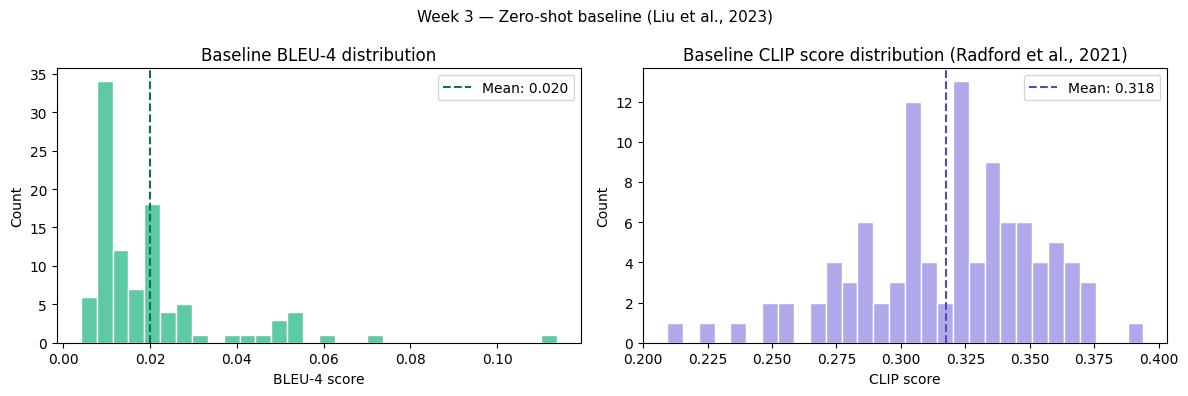

Saved: /content/drive/MyDrive/dissertation_final/results/week3_baseline_distributions.png


In [10]:
# ── CELL 10 — Plot distributions (Figure 1) ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(results_df['bleu4'], bins=30, edgecolor='white', color='#5DCAA5')
axes[0].axvline(results_df['bleu4'].mean(), color='#0F6E56', linestyle='--',
                label=f'Mean: {results_df["bleu4"].mean():.3f}')
axes[0].set_xlabel('BLEU-4 score')
axes[0].set_ylabel('Count')
axes[0].set_title('Baseline BLEU-4 distribution')
axes[0].legend()

axes[1].hist(results_df['clip_score'], bins=30, edgecolor='white', color='#AFA9EC')
axes[1].axvline(results_df['clip_score'].mean(), color='#534AB7', linestyle='--',
                label=f'Mean: {results_df["clip_score"].mean():.3f}')
axes[1].set_xlabel('CLIP score')
axes[1].set_ylabel('Count')
axes[1].set_title('Baseline CLIP score distribution (Radford et al., 2021)')
axes[1].legend()

plt.suptitle('Week 3 — Zero-shot baseline (Liu et al., 2023)', fontsize=11)
plt.tight_layout()
out = f'{RESULTS_DIR}/week3_baseline_distributions.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

In [11]:
# ── CELL 11 — Final verification ──────────────────────────────────────────
print('='*55)
print('Week 3 — Final verification')
print('='*55)
for f in [f'{RESULTS_DIR}/week3_baseline.csv',
          f'{RESULTS_DIR}/results_table.csv',
          f'{RESULTS_DIR}/week3_baseline_distributions.png']:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) if exists else 0
    print(f'  [{"OK" if exists else "MISSING"}] {os.path.basename(f):40s} {size:>10,} bytes')
print()
print(f'Baseline BLEU-4    : {aggregate["bleu_4"]}')
print(f'Baseline CLIP score: {aggregate["clip_score_mean"]}')
print()
print('Week 3 complete. Next: week4_prompts_colab.ipynb')

Week 3 — Final verification
  [OK] week3_baseline.csv                           79,069 bytes
  [OK] results_table.csv                               123 bytes
  [OK] week3_baseline_distributions.png             60,115 bytes

Baseline BLEU-4    : 0.0212
Baseline CLIP score: 0.3176

Week 3 complete. Next: week4_prompts_colab.ipynb
